# Asteroid Colour Computation
Computes B-V, V-R, V-I colour indices from multi-filter photometry.

**Formula:** $m_{calib} = -2.5 \\log_{10}(F) - A - Z - \\kappa X$

In [27]:
# ── Parameters — edit these before running ─────────────────────────────────────

TARGET   = "2001_FD58"   # Target folder name
MAIN_DIR = "."         # Path to the folder containing the target subfolder

# Instrument constant (TRAPPIST North)
A_INSTRUMENT = -25.0

# Filter parameters from Farnham Table VI
# kappa = atmospheric extinction coefficient (col 7)
# ZP    = photometric zero point              (col 8)
FILTER_PARAMS = {
    "B": {"kappa": 0.25,  "ZP": 2.297},
    "V": {"kappa": 0.14,  "ZP": 2.445},
    "R": {"kappa": 0.098, "ZP": 2.122},
    "I": {"kappa": 0.043, "ZP": 2.605},
}

# Colour indices to compute: (filter1 - filter2)
COLOUR_INDICES = [
    ("B", "V"),   # B - V
    ("V", "R"),   # V - R
    ("V", "I"),   # V - I
]

# Conversion order for final mean plot:
#   'mag_first'  : convert to magnitude first, then subtract  (standard)
#   'flux_first' : subtract fluxes first, then convert to magnitude
#   'both'       : show both side by side
CONVERSION_ORDER = "mag_first"
# CONVERSION_ORDER = "both"


In [28]:
import os, sys, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from utils.photometry import flux_to_mag, weighted_mean, colour_index


In [29]:
# ── Discover folder structure ──────────────────────────────────────────────────
# Expected: MAIN_DIR / TARGET / YY-MM-DD / filter-X / XXh / *.dat

target_dir   = MAIN_DIR
date_pattern = re.compile(r"^\d{2}_\d{2}_\d{2}$")
hour_pattern = re.compile(r"^\d{2}h$")
FILTERS      = ["B", "V", "R", "I"]

dates = sorted([d for d in os.listdir(target_dir)
                if os.path.isdir(os.path.join(target_dir, d)) and date_pattern.match(d)])

if not dates:
    raise FileNotFoundError(f"No date folders (YY_MM_DD) found in {target_dir}")

print(f"Target : {TARGET}")
print(f"Dates  : {dates}")
print(f"Filters: {FILTERS}")


Target : 2001_FD58
Dates  : ['26_02_21', '26_02_22']
Filters: ['B', 'V', 'R', 'I']


In [30]:
# ── Helper: read a single .dat file ───────────────────────────────────────────

def read_dat(path):
    df = pd.read_csv(path, sep="\t", comment=None, header=0)
    df.columns = [c.lstrip("#").strip() for c in df.columns]
    required = ["J.D.-2400000", "rel_flux_T1", "rel_flux_err_T1", "airmass"]
    missing  = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns {missing} in {path}")
    return df


# ── Helper: weighted mean over all measurements in a hour folder ───────────────

def load_hour_folder(folder_path):
    dat_files = sorted([f for f in os.listdir(folder_path) if f.endswith(".dat")])
    if not dat_files:
        raise FileNotFoundError(f"No .dat files in {folder_path}")

    all_flux, all_err, all_jd, all_air = [], [], [], []
    for fname in dat_files:
        df = read_dat(os.path.join(folder_path, fname))
        all_flux.extend(df["rel_flux_T1"].tolist())
        all_err.extend(df["rel_flux_err_T1"].tolist())
        all_jd.extend(df["J.D.-2400000"].tolist())
        all_air.extend(df["airmass"].tolist())

    all_flux = np.array(all_flux)
    all_err  = np.array(all_err)
    all_jd   = np.array(all_jd)
    all_air  = np.array(all_air)

    weights        = 1.0 / all_err**2
    flux_mean      = np.sum(weights * all_flux) / np.sum(weights)
    flux_err_mean  = 1.0 / np.sqrt(np.sum(weights))
    air_mean       = np.average(all_air, weights=weights)
    jd_mean        = np.mean(all_jd)

    return flux_mean, flux_err_mean, air_mean, jd_mean


In [31]:
# ── Load all data ──────────────────────────────────────────────────────────────
# records[date][filter][hour] = {flux, flux_err, airmass, jd}

def load_filter_folder(filt_dir):
    """
    Handle two possible structures:
      - filt_dir / XXh / *.dat   (multiple hours)
      - filt_dir / *.dat         (single hour, no subfolder)
    Returns a dict: {hour_label: {flux, flux_err, airmass, jd}}
    """
    # Check if there are any hour subfolders
    hours = sorted([h for h in os.listdir(filt_dir)
                    if os.path.isdir(os.path.join(filt_dir, h)) and hour_pattern.match(h)])

    if hours:
        # Normal case: one subfolder per hour
        return {hour: dict(zip(
                    ["flux", "flux_err", "airmass", "jd"],
                    load_hour_folder(os.path.join(filt_dir, hour))
                )) for hour in hours}
    else:
        # Flat case: .dat files directly in the filter folder
        dat_files = [f for f in os.listdir(filt_dir) if f.endswith(".dat")]
        if not dat_files:
            raise FileNotFoundError(f"No .dat files or hour subfolders in {filt_dir}")
        flux, flux_err, airmass, jd = load_hour_folder(filt_dir)
        return {"00h": {"flux": flux, "flux_err": flux_err, "airmass": airmass, "jd": jd}}
    
    
records = {}
for date in dates:
    date_dir = os.path.join(target_dir, date)
    records[date] = {}
    for filt in FILTERS:
        filt_dir = os.path.join(date_dir, f"filter-{filt}")
        if not os.path.isdir(filt_dir):
            raise FileNotFoundError(f"Missing filter folder for {filt} on {date}:\n  {filt_dir}")
        records[date][filt] = load_filter_folder(filt_dir)
        for hour, vals in records[date][filt].items():
            print(f"  {date} / filter-{filt} / {hour} : flux={vals['flux']:.5f} +/- {vals['flux_err']:.5f}, X={vals['airmass']:.3f}")

print("\nAll data loaded successfully.")


  26_02_21 / filter-B / 03h : flux=0.64554 +/- 0.02415, X=2.012
  26_02_21 / filter-B / 22h : flux=0.53845 +/- 0.00426, X=1.010
  26_02_21 / filter-V / 03h : flux=0.48208 +/- 0.00746, X=2.039
  26_02_21 / filter-V / 22h : flux=0.59877 +/- 0.00330, X=1.011
  26_02_21 / filter-R / 03h : flux=0.77499 +/- 0.01114, X=1.984
  26_02_21 / filter-R / 22h : flux=0.51910 +/- 0.00187, X=1.009
  26_02_21 / filter-I / 03h : flux=0.47522 +/- 0.00749, X=2.067
  26_02_21 / filter-I / 22h : flux=0.64601 +/- 0.00481, X=1.012
  26_02_22 / filter-B / 01h : flux=0.23306 +/- 0.00195, X=1.330
  26_02_22 / filter-B / 20h : flux=0.56632 +/- 0.02475, X=1.051
  26_02_22 / filter-V / 01h : flux=0.29099 +/- 0.00165, X=1.340
  26_02_22 / filter-V / 20h : flux=0.09472 +/- 0.00118, X=1.049
  26_02_22 / filter-R / 01h : flux=0.27442 +/- 0.00104, X=1.320
  26_02_22 / filter-R / 20h : flux=0.09012 +/- 0.00091, X=1.056
  26_02_22 / filter-I / 01h : flux=0.30178 +/- 0.00144, X=1.349
  26_02_22 / filter-I / 20h : flux=0.289

In [32]:
# ── Convert flux to magnitude for each hour ────────────────────────────────────
# mags[date][filter][hour] = {mag, mag_err, jd}

mags = {}
for date in dates:
    mags[date] = {}
    for filt in FILTERS:
        mags[date][filt] = {}
        for hour, vals in records[date][filt].items():
            mag, mag_err = flux_to_mag(
                vals["flux"], vals["flux_err"],
                filt, vals["airmass"],
                A=A_INSTRUMENT
            )
            mags[date][filt][hour] = {"mag": float(mag), "mag_err": float(mag_err), "jd": vals["jd"]}


In [33]:
# ── Compute colour indices per observation hour ────────────────────────────────
# Two methods:
#   mag_first  : mag(f1) - mag(f2)                        (standard)
#   flux_first : -2.5*log10(flux_f1 - flux_f2)            (for comparison)

def compute_hourly_colours(records, mags, dates, colour_indices):
    hourly_mf = {date: {} for date in dates}
    hourly_ff = {date: {} for date in dates}

    for date in dates:
        for f1, f2 in colour_indices:
            label  = f"{f1}-{f2}"
            common = sorted(set(mags[date][f1].keys()) & set(mags[date][f2].keys()))
            if not common:
                print(f"  WARNING: no common hours for {label} on {date} — skipping")
                continue
            hourly_mf[date][label] = []
            hourly_ff[date][label] = []
            for hour in common:
                jd = np.mean([mags[date][f1][hour]["jd"], mags[date][f2][hour]["jd"]])
                # mag_first
                m1, e1 = mags[date][f1][hour]["mag"], mags[date][f1][hour]["mag_err"]
                m2, e2 = mags[date][f2][hour]["mag"], mags[date][f2][hour]["mag_err"]
                col, col_err = colour_index(m1, e1, m2, e2)
                hourly_mf[date][label].append((jd, col, col_err))
                # flux_first
                r1, r2 = records[date][f1][hour], records[date][f2][hour]
                fd  = r1["flux"] - r2["flux"]
                fde = np.sqrt(r1["flux_err"]**2 + r2["flux_err"]**2)
                if fd > 0:
                    col_ff     = -2.5 * np.log10(fd)
                    col_ff_err = (2.5 / np.log(10)) * (fde / fd)
                else:
                    col_ff, col_ff_err = np.nan, np.nan
                hourly_ff[date][label].append((jd, col_ff, col_ff_err))
    return hourly_mf, hourly_ff


hourly_mf, hourly_ff = compute_hourly_colours(records, mags, dates, COLOUR_INDICES)
print("Hourly colour indices computed.")


Hourly colour indices computed.


In [34]:
# ── Nightly weighted means ─────────────────────────────────────────────────────

def nightly_means(hourly):
    result = {date: {} for date in dates}
    for date in dates:
        for label, entries in hourly[date].items():
            vals  = np.array([e[1] for e in entries])
            errs  = np.array([e[2] for e in entries])
            valid = ~np.isnan(vals) & ~np.isnan(errs) & (errs > 0)
            if valid.sum() == 0:
                result[date][label] = (np.nan, np.nan)
            else:
                result[date][label] = weighted_mean(vals[valid], errs[valid])
    return result


nightly_mf = nightly_means(hourly_mf)
nightly_ff = nightly_means(hourly_ff)

print("Nightly means (mag_first):")
for date in dates:
    for label, (m, e) in nightly_mf[date].items():
        print(f"  {date}  {label} = {m:.4f} +/- {e:.4f}")


Nightly means (mag_first):
  26_02_21  B-V = 0.1234 +/- 0.0102
  26_02_21  V-R = -0.4655 +/- 0.0068
  26_02_21  V-I = 0.1150 +/- 0.0093
  26_02_22  B-V = 0.1422 +/- 0.0107
  26_02_22  V-R = -0.4411 +/- 0.0068
  26_02_22  V-I = 0.2691 +/- 0.0074


In [35]:
# ── Overall weighted means across all nights ──────────────────────────────────

def overall_means(nightly):
    labels = sorted(set(lbl for date in dates for lbl in nightly[date]))
    result = {}
    for label in labels:
        vals  = np.array([nightly[d][label][0] for d in dates if label in nightly[d]])
        errs  = np.array([nightly[d][label][1] for d in dates if label in nightly[d]])
        valid = ~np.isnan(vals) & ~np.isnan(errs) & (errs > 0)
        result[label] = weighted_mean(vals[valid], errs[valid]) if valid.sum() > 0 else (np.nan, np.nan)
    return result


overall_mf = overall_means(nightly_mf)
overall_ff = overall_means(nightly_ff)

print(f"{'Index':<8} {'mag_first':>20} {'flux_first':>20}")
print("-" * 52)
for label in sorted(overall_mf):
    m1, e1 = overall_mf[label]
    m2, e2 = overall_ff[label]
    print(f"{label:<8} {m1:>8.4f} +/- {e1:<8.4f}   {m2:>8.4f} +/- {e2:<8.4f}")


Index               mag_first           flux_first
----------------------------------------------------
B-V        0.1323 +/- 0.0074       0.9351 +/- 0.0540  
V-I        0.2097 +/- 0.0058       5.4083 +/- 1.6725  
V-R       -0.4533 +/- 0.0048       3.0382 +/- 0.0475  


In [36]:
# ── Plot styling ──────────────────────────────────────────────────────────────

COLOUR_STYLES = {
    "B-V": {"color": "royalblue",  "marker": "o"},
    "V-R": {"color": "forestgreen", "marker": "s"},
    "V-I": {"color": "tomato",      "marker": "^"},
}

def _style_ax(ax):
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.grid(visible=True, which="major", linestyle="--", alpha=0.4)

colour_labels = [f"{f1}-{f2}" for f1, f2 in COLOUR_INDICES]


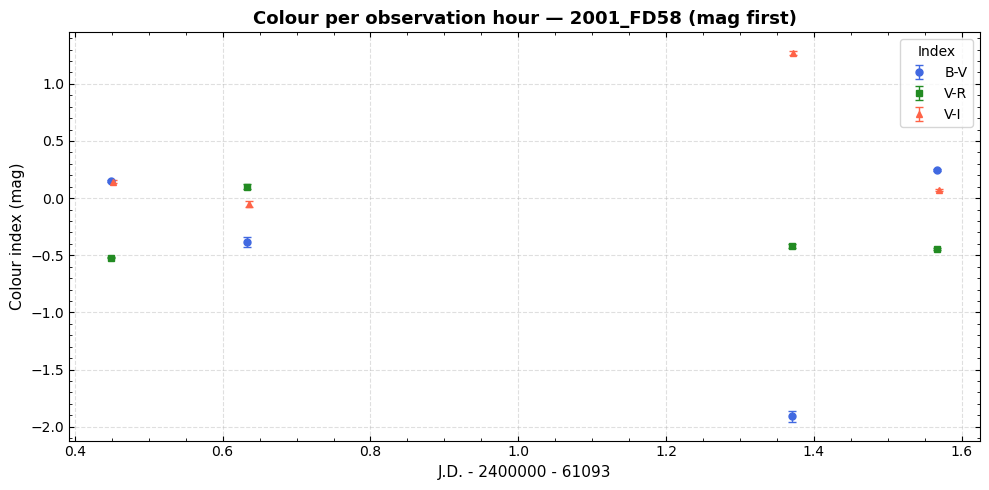

In [37]:
# ── Plot 1: Colour per observation hour ───────────────────────────────────────

def plot_colours_per_hour(hourly, title_suffix=""):
    fig, ax = plt.subplots(figsize=(10, 5))
    jd_offset = int(min(
        e[0] for date in dates for label in colour_labels
        for e in hourly[date].get(label, [])
    ))
    for label in colour_labels:
        all_jds, all_cols, all_errs = [], [], []
        for date in dates:
            for jd, col, err in hourly[date].get(label, []):
                if not np.isnan(col):
                    all_jds.append(jd)
                    all_cols.append(col)
                    all_errs.append(err)
        if all_jds:
            ax.errorbar(
                np.array(all_jds) - jd_offset, all_cols, yerr=all_errs,
                fmt=COLOUR_STYLES[label]["marker"], markersize=5,
                color=COLOUR_STYLES[label]["color"],
                elinewidth=1, capsize=3, linewidth=0, label=label
            )
    ax.set_xlabel(f"J.D. - 2400000 - {jd_offset}", fontsize=11)
    ax.set_ylabel("Colour index (mag)", fontsize=11)
    ax.set_title(f"Colour per observation hour — {TARGET}{title_suffix}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10, title="Index")
    _style_ax(ax)
    fig.tight_layout()
    plt.show()



if CONVERSION_ORDER in ("mag_first", "both"):
    plot_colours_per_hour(hourly_mf, " (mag first)")
if CONVERSION_ORDER in ("flux_first", "both"):
    plot_colours_per_hour(hourly_ff, " (flux first)")


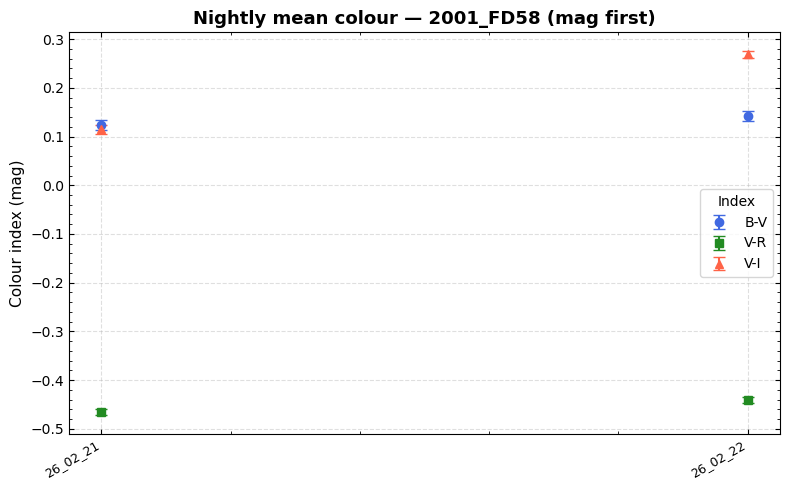

In [38]:
# ── Plot 2: Nightly mean colour ────────────────────────────────────────────────

def plot_colours_per_night(nightly, title_suffix=""):
    fig, ax = plt.subplots(figsize=(8, 5))
    x_pos = np.arange(len(dates))
    for label in colour_labels:
        cols = [nightly[d].get(label, (np.nan, np.nan))[0] for d in dates]
        errs = [nightly[d].get(label, (np.nan, np.nan))[1] for d in dates]
        ax.errorbar(
            x_pos, cols, yerr=errs,
            fmt=COLOUR_STYLES[label]["marker"], markersize=6,
            color=COLOUR_STYLES[label]["color"],
            elinewidth=1.5, capsize=4, linewidth=0, label=label
        )
    ax.set_xticks(x_pos)
    ax.set_xticklabels(dates, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Colour index (mag)", fontsize=11)
    ax.set_title(f"Nightly mean colour — {TARGET}{title_suffix}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10, title="Index")
    _style_ax(ax)
    fig.tight_layout()
    plt.show()





if CONVERSION_ORDER in ("mag_first", "both"):
    plot_colours_per_night(nightly_mf, " (mag first)")
if CONVERSION_ORDER in ("flux_first", "both"):
    plot_colours_per_night(nightly_ff, " (flux first)")


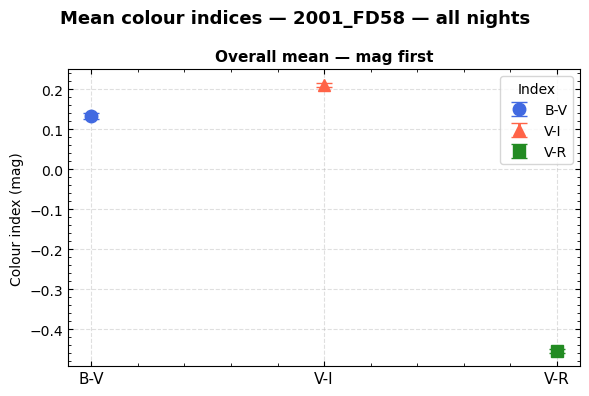

In [39]:
# ── Plot 3: Overall mean across all nights ─────────────────────────────────────

def plot_overall_means(overall_mf, overall_ff, conversion_order):
    labels = sorted(overall_mf.keys())
    x_pos  = np.arange(len(labels))

    if conversion_order == "both":
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        datasets = [(axes[0], overall_mf, "mag first"), (axes[1], overall_ff, "flux first")]
    elif conversion_order == "mag_first":
        fig, ax = plt.subplots(figsize=(6, 4))
        datasets = [(ax, overall_mf, "mag first")]
    else:
        fig, ax = plt.subplots(figsize=(6, 4))
        datasets = [(ax, overall_ff, "flux first")]

    for ax, overall, method in datasets:
        for i, label in enumerate(labels):
            m, e = overall[label]
            ax.errorbar(
                i, m, yerr=e,
                fmt=COLOUR_STYLES[label]["marker"], markersize=9,
                color=COLOUR_STYLES[label]["color"],
                elinewidth=2, capsize=6, linewidth=0, label=label
            )
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, fontsize=11)
        ax.set_ylabel("Colour index (mag)", fontsize=10)
        ax.set_title(f"Overall mean — {method}", fontsize=11, fontweight="bold")
        ax.legend(fontsize=10, title="Index")
        _style_ax(ax)

    fig.suptitle(f"Mean colour indices — {TARGET} — all nights", fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()


plot_overall_means(overall_mf, overall_ff, CONVERSION_ORDER)
